# **PyTorch Distributed Data Parallel for Animal Pose Estimation**

This notebook presents a complete pipeline for training, evaluation, and inference on multiple GPUs using **PyTorch's Distributed Data Parallel (DDP)** strategy. Distributed training is essential as datasets grow larger and models scale to millions or even billions of parameters such as modern **VLMs** and **LLMs** since training on a single GPU can become inefficient, extremely slow, and memory constrained.

In this specific case, distributed training is applied to an **animal pose estimation** task using a **bottom-up** approach, where the model predicts keypoints via heatmaps, generating output maps with the same spatial resolution as the input images. This type of task demands significantly more computational power than other computer vision tasks, such as image classification, object detection, segmentation, or others pose estimation methods, making it an excellent scenario to benchmark distributed training performance.

#### **Context and Hardware Comparison**

The same task, using the [CUB-200-2011](https://www.vision.caltech.edu/datasets/cub_200_2011/) dataset and a model with over **100 million parameters**, was previously implemented in my repository using distributed training with **TensorFlow** on Google Colab's **TPU v2-8**, with an input resolution of **(384, 384)**. In this notebook, training is performed on Kaggle's **T4x2 GPUs** with an input size of **(256, 256)** to speed up the process, as even two 15GB GPUs are insufficient to match the performance achieved by TensorFlow on an 8-core TPU.

However, in another project where I developed a full distributed training pipeline using **PyTorch/XLA** on Kaggle's **TPU v5e-8**, I achieved even faster training speeds than with TensorFlow, while maintaining the same **(384, 384)** input resolution.

For this and other Deep Learning projects, you can visit my repository: [**Computer Vision**](https://github.com/JersonGB22/ComputerVision).

## **Environment Setup and Data Preparation**

In [4]:
!pip install torchmetrics github-clone pydantic==2.11.10 kaleido==0.2.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 25.7 MB/s eta 0:00:00


The **CUB-200-2011** dataset download and detailed preprocessing for pose estimation were completed in the following notebook: [**Preprocessing_CUB-200-2011**](https://github.com/JersonGB22/PoseEstimation-TensorFlow-PyTorch/blob/main/Preprocessing/Preprocessing_CUB-200-2011.ipynb). Additionally, three utility scripts are provided in the **utils** folder of this [repository](https://github.com/JersonGB22/PoseEstimation-TensorFlow-PyTorch/).
These scripts implement data augmentation, dataset creation, model construction, learning rate scheduling, loss and metrics, and visualization utilities for predictions and training/validation curves.


In [ ]:
# Download the utils folder containing the helper scripts
!ghclone https://github.com/JersonGB22/PoseEstimation-TensorFlow-PyTorch/tree/main/pytorch_xla_ddp/utils

# Download and extract the CUB-200-2011 dataset
!gdown 1lNNnxgHV0N7UqXo3vh_84Wd08LENsUyL
!unzip -q CUB-200-2011.zip

Cloning into 'utils'...
done.
Downloading...
From (original): https://drive.google.com/uc?id=1lNNnxgHV0N7UqXo3vh_84Wd08LENsUyL
From (redirected): https://drive.google.com/uc?id=1lNNnxgHV0N7UqXo3vh_84Wd08LENsUyL&confirm=t&uuid=95bc5f1d-fa96-4797-a9c5-0f2a301dbb20
To: /content/CUB-200-2011.zip
100% 1.14G/1.14G [00:17<00:00, 66.2MB/s]


## **Defining the DDP Training Script**

In [ ]:
%%writefile train_ddp.py

import torch
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.utils.data import DataLoader
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torchmetrics.classification import Accuracy
from torchmetrics.aggregation import MeanMetric

from utils.data_module import PoseDataset, heatmaps_to_keypoints
from utils.model_module import (
    ConvNeXtPoseUNet, polynomial_lr_scheduler,
    PoseLoss, OKSMetric, PCKMetric
)
import argparse
import pandas as pd
import numpy as np
from tqdm import tqdm
import json
import os


def parse_args(cli_args: list[str] | None = None) -> argparse.Namespace:
    """
    Parses command-line arguments for DDP training. This function defines and parses arguments
    needed for distributed training, data loading, model configuration, and evaluation.

    Args:
        cli_args: A list of string arguments to parse. If None, defaults to 'sys.argv[1:]'.

    Returns:
        An object containing all parsed and processed arguments.
    """
    p = argparse.ArgumentParser(description="Distributed pose estimation training with PyTorch (DDP).")

    # General setup
    p.add_argument(
        "--run_mode", default="training", type=str,
        choices=["training", "evaluation", "inference"],
        help="Execution mode: training, evaluation or inference."
    )
    p.add_argument(
        "--dist_url", default="tcp://127.0.0.1:23456", type=str,
        help="URL specifying how to initialize the process group."
    )
    p.add_argument(
        "--dist_backend", default="nccl", type=str,
        help="Distributed backend (e.g., 'nccl', 'gloo')."
    )

    # Dataset setup
    p.add_argument(
        "--data_dir", default=os.getcwd(), type=str,
        help="Path to the dataset directory (must contain 'metadata.json')."
    )
    p.add_argument(
        "--batch_size", default=16, type=int,
        help="Global batch size."
    )
    p.add_argument(
        "--num_workers", default=os.cpu_count(), type=int,
        help="Global number of data loader workers."
    )
    p.add_argument(
        "--img_mean", nargs=3, default=[0.485, 0.456, 0.406], type=float,
        help="Mean for image normalization. (Default: ConvNeXtBase)."
    )
    p.add_argument(
        "--img_std", nargs=3, default=[0.229, 0.224, 0.225], type=float,
        help="Std deviation for image normalization. (Default: ConvNeXtBase)."
    )
    p.add_argument(
        "--img_size", nargs=2, default=[256, 256], type=int,
        help="Dimensions to resize images: (height, width)."
    )
    p.add_argument(
        "--kernel_size", nargs=2, default=[33, 33], type=int,
        help="Gaussian kernel size for heatmap generation."
    )
    p.add_argument(
        "--heatmap_sigma", default=6.0, type=float,
        help="Standard deviation for the Gaussian heatmap."
    )

    # Training setup
    p.add_argument(
        "--ckpt_dir", default=os.path.join(os.getcwd(), "ckpt"), type=str,
        help="Directory to save model checkpoints."
    )
    p.add_argument(
        "--resume_ckpt", action="store_true", default=False,
        help="Resume training from the latest checkpoint if set."
    )
    p.add_argument(
        "--epochs", default=10, type=int,
        help="Number of training epochs."
    )
    p.add_argument(
        "--lr0", default=1e-3, type=float,
        help="Initial learning rate."
    )
    p.add_argument(
        "--lrf", default=1e-4, type=float,
        help="Final learning rate for scheduler."
    )
    p.add_argument(
        "--power", default=2.0, type=float,
        help="Polynomial decay exponent for learning rate scheduler."
    )
    p.add_argument(
        "--patience", default=1, type=int,
        help="Epochs with no improvement before early stopping."
    )
    p.add_argument(
        "--monitor", default="val_oks", type=str,
        help="Metric to monitor for early stopping."
    )
    p.add_argument(
        "--mode", default="max", type=str,
        help="Whether to minimize or maximize the monitored metric."
    )

    # Evaluation and inference setup
    p.add_argument(
        "--eval_set", default="val", type=str, choices=["train", "val", "test"],
        help="Dataset split for validation in 'training' or 'evaluation' mode."
    )
    p.add_argument(
        "--inf_set", default="val", type=str, choices=["train", "val", "test"],
        help="Dataset split to run inference on."
    )
    p.add_argument(
        "--inf_steps", default=None, type=int,
        help="Total steps (batches) for inference. If None, evaluates the entire set."
    )

    # Metrics setup
    p.add_argument(
        "--oks_sigmas", nargs="+", default=None, type=float,
        help="OKS sigmas of length nkpts. If None, defaults to 1/nkpts for all."
    )
    p.add_argument(
        "--alpha", default=0.05, type=float,
        help="Threshold for PCK metric."
    )

    args = p.parse_args(cli_args)

    # Load metadata from the dataset directory
    with open(os.path.join(args.data_dir, "metadata.json")) as f:
        metadata = json.load(f)

    # Attach metadata-derived fields to args
    args.symmetric_kpts = metadata["symmetric_kpts"]
    args.skeleton = metadata["skeleton"]
    args.nkpts = metadata["nkpts"]

    # Convert normalization params to torch tensors
    args.img_mean = torch.tensor(args.img_mean, dtype=torch.float32)
    args.img_std = torch.tensor(args.img_std, dtype=torch.float32)

    # If oks_sigmas was not provided, use uniform defaults
    if args.oks_sigmas is None:
        args.oks_sigmas = np.ones(args.nkpts) / args.nkpts

    return args


def build_data_pipeline(
    args: argparse.Namespace,
    rank: int,
    device: torch.device,
    split: str = "train",
    training: bool = True
) -> tuple[PoseDataset, DistributedSampler | None, DataLoader]:
    """
    Initializes and configures the data pipeline for a given split. This function sets up
    the PoseDataset, DistributedSampler (if in DDP mode), and the DataLoader. It correctly
    handles per-replica batch sizing and worker allocation for distributed training.

    Args:
        args: Parsed command-line arguments.
        rank: The global rank of the current process (0 to world_size - 1).
        device: The device for the current rank.
        split: The dataset split to load.
        training: If True, enables training mode (e.g., data augmentation, shuffling).

    Returns:
        A tuple containing the dataset, sampler and dataloader.
    """
    dataset = PoseDataset(args, split, training)
    sampler = DistributedSampler(dataset, shuffle=training, drop_last=True) if args.distributed else None
    loader = DataLoader(
        dataset,
        batch_size=args.batch_size // args.world_size,
        shuffle=(sampler is None) and training,
        sampler=sampler,
        num_workers=args.num_workers // args.world_size,
        pin_memory=device.type == "cuda",
        drop_last=False
    )

    # Print dataset summary only on the main process
    if rank == 0:
        print(
            f"{split.capitalize().rjust(5) if args.run_mode == 'training' else split.capitalize()} dataset: "
            f"size={len(dataset)}, "
            f"deleted_records={len(dataset) % args.world_size}"
        )

    return dataset, sampler, loader


class DDPTrainer():
    """
    A high-level trainer class to manage Distributed Data Parallel (DDP),
    single-GPU, and CPU-only workflows.
    This class encapsulates the entire training, evaluation, and inference
    lifecycle for a pose estimation model. It handles DDP setup,
    model and metric initialization, checkpointing, and results aggregation.

    Args:
        rank: The global rank of the current process.
        device: The device for the current rank.
        args: Parsed command-line arguments.
    """

    def __init__(self, rank: int, device: torch.device, args: argparse.Namespace):
        self.rank = rank
        self.device = device
        self.args = args

        self.model = ConvNeXtPoseUNet(args.nkpts).to(device=device)
        if args.distributed:
            # Use channels_last memory format for potential DDP performance boost
            self.model = self.model.to(memory_format=torch.channels_last)

        # Instantiate metrics and loss function. TorchMetrics handles DDP synchronization.
        self.criterion = PoseLoss
        self.loss_metric = MeanMetric().to(device)

        self.oks_metric = OKSMetric(args.oks_sigmas).to(device)
        self.pck_metric = PCKMetric(args.alpha).to(device)
        self.acc_metric = Accuracy(task="binary").to(device)

    def run_epoch(
        self,
        loader: DataLoader,
        phase: str = "train",
        training: bool = True
    ) -> dict[str, float]:
        """
        Runs one epoch of training or validation.

        Args:
            loader: The DataLoader for the epoch.
            phase: Name of the phase ('train', 'val' or 'test').
            training: True for training, False for evaluation.

        Returns:
            Metric results from the epoch.
        """
        # Switch model mode depending on phase
        self.model.train() if training else self.model.eval()

        # Reset metrics at epoch start
        self.loss_metric.reset()
        if not training:
            self.oks_metric.reset()
            self.pck_metric.reset()
            self.acc_metric.reset()

        # Progress bar setup (Rank 0 only)
        desc = phase.capitalize().rjust(5) if self.args.run_mode == "training" else phase.capitalize()
        phase = "" if phase == "train" else phase + "_"
        if self.rank == 0:
            pbar = tqdm(desc=desc, total=len(loader), ncols=130, bar_format="{l_bar}{bar:10}{r_bar}")

        for batch in loader:
            images = batch["images"].to(self.device, non_blocking=True)
            heatmaps = batch["heatmaps"].to(self.device, non_blocking=True)

            # Enable gradient computation if the model is in training mode
            with torch.set_grad_enabled(training):
                if training:
                    self.optimizer.zero_grad()

                # Forward pass
                heatmaps_pred = self.model(images)
                loss = self.criterion(heatmaps_pred, heatmaps)

                # Backward + optimizer step
                if training:
                    loss.backward()
                    self.optimizer.step()
                    self.scheduler.step()

            # Update metrics
            self.loss_metric.update(loss.detach(), weight=len(heatmaps))
            if not training:
                keypoints = batch["keypoints"].to(self.device, non_blocking=True)
                bboxes = batch["bboxes"].to(self.device, non_blocking=True)

                # Compute predicted keypoints, segmentation areas and bbox diagonals
                keypoints_pred = heatmaps_to_keypoints(heatmaps_pred.detach())
                areas = torch.prod(bboxes[:, 2:], dim=1) * 0.53
                diagonals = torch.linalg.norm(bboxes[:, 2:], dim=1)

                self.oks_metric.update(keypoints_pred, keypoints, areas)
                self.pck_metric.update(keypoints_pred, keypoints, diagonals)
                self.acc_metric.update(
                    (keypoints_pred[..., 2] > 0).float(),
                    (keypoints[..., 2] > 0).float()
                )

            # Compute metric results for the current batch
            # The 'compute' method syncs all processes (DDP) and returns the global results
            global_loss = self.loss_metric.compute().item()
            results = {f"{phase}loss": global_loss}

            if not training:
                global_oks = self.oks_metric.compute().item()
                global_pck = self.pck_metric.compute().item()
                global_acc = self.acc_metric.compute().item()

                results.update({
                    f"{phase}oks": global_oks,
                    f"{phase}pck": global_pck,
                    f"{phase}accuracy": global_acc,
                })

            if training:
                results["lr"] = self.scheduler.get_last_lr()[0]

            # Only rank 0 updates the progress bar
            if self.rank == 0:
                pbar.update(1)
                pbar.set_postfix(results)

        return results

    def train(self) -> None:
        """
        Orchestrates the full training process, including data setup,
        checkpoint resumption, the main epoch loop, and early stopping.
        """
        # Setup data pipelines
        train_dataset, train_sampler, train_loader = build_data_pipeline(
            self.args, self.rank, self.device, split="train", training=True
        )
        val_dataset, val_sampler, val_loader = build_data_pipeline(
            self.args, self.rank, self.device, split=self.args.eval_set, training=False
        )

        # Setup optimizer and scheduler
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.args.lr0)
        self.scheduler = polynomial_lr_scheduler(
            self.optimizer, len(train_loader) * self.args.epochs,
            self.args.lr0, self.args.lrf, self.args.power
        )

        # Checkpoint Resumption and training history
        if self.args.resume_ckpt:
            history = pd.read_csv(os.path.join(self.args.ckpt_dir, "history.csv"))
            checkpoint = torch.load(os.path.join(self.args.ckpt_dir, "last.pth"), weights_only=True)

            self.model.load_state_dict(checkpoint["model"])
            self.optimizer.load_state_dict(checkpoint["optimizer"])
            self.scheduler.load_state_dict(checkpoint["scheduler"])
            del checkpoint

            # Restore early stopping state
            values = history[self.args.monitor]
            best_value = values.min() if self.args.mode == "min" else values.max()
            wait = len(history) - (values.idxmin() if self.args.mode == "min" else values.idxmax()) - 1

        else:
            os.makedirs(self.args.ckpt_dir, exist_ok=True)
            history = pd.DataFrame(columns=[
                "loss", "lr",
                f"{self.args.eval_set}_loss", f"{self.args.eval_set}_oks",
                f"{self.args.eval_set}_pck", f"{self.args.eval_set}_accuracy"
            ])

            best_value = float("inf") if self.args.mode == "min" else float("-inf")
            wait = 0

        # DDP model wrapping
        if self.args.distributed:
            self.model = DDP(self.model, device_ids=[self.rank])

        # Display parameter count only on main process
        if self.rank == 0:
            total_params = sum(p.numel() for p in self.model.parameters())
            print(f"\nTotal model parameters: {total_params:,}\n")

        for epoch in range(len(history) + 1, self.args.epochs + 1):
            # Set epoch to ensure proper shuffling in DistributedSampler
            if self.args.distributed:
                train_sampler.set_epoch(epoch)

            if self.rank == 0:
                print(f"Epoch {epoch}/{self.args.epochs}")

            train_results = self.run_epoch(train_loader, phase="train", training=True)
            val_results = self.run_epoch(val_loader, phase=self.args.eval_set, training=False)
            if self.rank == 0:
                print()

            # Update history
            train_results.update(val_results)
            history.loc[len(history)] = train_results

            # Save the last checkpoint
            if self.rank == 0:
                history.to_csv(os.path.join(self.args.ckpt_dir, "history.csv"), index=False)
                torch.save(
                    {
                        "model": self.model.module.state_dict() if self.args.distributed else self.model.state_dict(),
                        "optimizer": self.optimizer.state_dict(),
                        "scheduler": self.scheduler.state_dict()
                    },
                    os.path.join(self.args.ckpt_dir, "last.pth")
                )

            # Early stopping logic
            current_value = val_results[self.args.monitor]
            improved = current_value < best_value if self.args.mode == "min" else current_value > best_value
            if improved:
                # Save the best model weights
                if self.rank == 0:
                    torch.save(
                        self.model.module.state_dict() if self.args.distributed else self.model.state_dict(),
                        os.path.join(self.args.ckpt_dir, "best.pth")
                    )
                best_value = current_value
                wait = 0
            else:
                wait += 1

            # Trigger early stopping if no improvement for 'patience' epochs
            if wait >= self.args.patience:
                if self.rank == 0:
                    print(f"Early stopping triggered after {wait} epochs without improvement.")
                break

    def eval(self) -> None:
        """
        Runs evaluation using the best model weights and saves the results to a CSV.
        """
        dataset, sampler, loader = build_data_pipeline(
            self.args, self.rank, self.device, split=self.args.eval_set, training=False
        )

        # Load best model weights
        self.model.load_state_dict(torch.load(os.path.join(self.args.ckpt_dir, "best.pth"), weights_only=True))
        if self.args.distributed:
            self.model = DDP(self.model, device_ids=[self.rank])

        if self.rank == 0:
            total_params = sum(p.numel() for p in self.model.parameters())
            print(f"\nTotal parameters of the trained model: {total_params:,}\n")

        results = self.run_epoch(loader, self.args.eval_set, training=False)

        # Saves the evaluation results
        if self.rank == 0:
            pd.DataFrame([results]).to_csv(
                os.path.join(self.args.ckpt_dir, f"{self.args.eval_set}_results_{self.args.world_size}d.csv"),
                index=False
            )

    def predict(self) -> None:
        """
        Runs inference on a dataset split, gathers predictions from all
        DDP ranks, and saves them to a compressed .npz file.
        """
        dataset, sampler, loader = build_data_pipeline(
            self.args, self.rank, self.device, split=self.args.inf_set, training=False
        )
        img_mean = self.args.img_mean.to(self.device)
        img_std = self.args.img_std.to(self.device)

        # Load best model weights
        self.model.load_state_dict(torch.load(os.path.join(self.args.ckpt_dir, "best.pth"), weights_only=True))
        if self.args.distributed:
            self.model = DDP(self.model, device_ids=[self.rank])
        self.model.eval()

        # Collector lists, only used on rank 0
        if self.rank == 0:
            all_images = []
            all_keypoints = []
            all_bboxes = []
            all_keypoints_pred = []

            total_params = sum(p.numel() for p in self.model.parameters())
            print(f"\nTotal parameters of the trained model: {total_params:,}\n")

            pbar = tqdm(total=self.args.inf_steps or len(loader))

        with torch.no_grad():
            for idx, batch in enumerate(loader, 1):
                images = batch["images"].to(self.device, non_blocking=True)
                keypoints = batch["keypoints"].to(self.device, non_blocking=True)
                bboxes = batch["bboxes"].to(self.device, non_blocking=True)
                keypoints_pred = heatmaps_to_keypoints(self.model(images))

                # Denormalize images for saving
                images = images.permute(0, 2, 3, 1).contiguous()
                images = ((images * img_std) + img_mean) * 255

                # DDP Prediction Gathering
                if self.args.distributed:
                    # Get the batch size from each rank (can be variable)
                    size = torch.tensor([len(images)], dtype=torch.int32, device=self.device)
                    size_list = [torch.zeros_like(size) for _ in range(self.args.world_size)]
                    dist.all_gather(size_list, size)
                    size_list = torch.cat(size_list, dim=0)

                    # Gather all tensors from all replicas
                    images_list = self.all_gather_tensors(images, size_list)
                    keypoints_list = self.all_gather_tensors(keypoints, size_list)
                    bboxes_list = self.all_gather_tensors(bboxes, size_list)
                    keypoints_pred_list = self.all_gather_tensors(keypoints_pred, size_list)

                else:
                    images_list = [images]
                    keypoints_list = [keypoints]
                    bboxes_list = [bboxes]
                    keypoints_pred_list = [keypoints_pred]

                # Append results
                if self.rank == 0:
                    all_images.append(torch.cat(images_list, dim=0).cpu().numpy())
                    all_keypoints.append(torch.cat(keypoints_list, dim=0).cpu().numpy())
                    all_bboxes.append(torch.cat(bboxes_list, dim=0).cpu().numpy())
                    all_keypoints_pred.append(torch.cat(keypoints_pred_list, dim=0).cpu().numpy())
                    pbar.update(1)

                if idx == self.args.inf_steps:
                    break

        # On the main process, save all collected results
        if self.rank == 0:
            np.savez_compressed(
                os.path.join(self.args.ckpt_dir, f"inf_{self.args.inf_set}_results_{self.args.world_size}d.npz"),
                images=np.concatenate(all_images, axis=0).astype(np.uint8),
                keypoints=np.concatenate(all_keypoints, axis=0).astype(np.int32),
                bboxes=np.concatenate(all_bboxes, axis=0).astype(np.float32),
                keypoints_pred=np.concatenate(all_keypoints_pred, axis=0).astype(np.int32)
            )

    def all_gather_tensors(self, tensor: torch.Tensor, size_list: torch.Tensor) -> list[torch.Tensor]:
        """
        Gathers tensors from all ranks into a list, handling variable batch sizes per rank.

        Args:
            tensor: The tensor from the current rank.
            size_list: A 1D tensor containing the batch size of the tensor on each rank.

        Returns:
            A list of tensors, one from each rank.
        """
        tensor_list = [
            torch.zeros((size_list[i],) + tensor.shape[1:], dtype=tensor.dtype, device=self.device)
            for i in range(self.args.world_size)
        ]
        dist.all_gather(tensor_list, tensor)
        return tensor_list


def main(rank: int, args: argparse.Namespace) -> None:
    """
    The main worker function for a single DDP process.

    Args:
        rank: The global rank of this process (0 to world_size - 1).
            This is automatically provided by mp.spawn() in distributed mode.
        args: Parsed command-line arguments.
    """
    # Set the device for this specific process
    device = torch.device(f"cuda:{rank}" if torch.cuda.is_available() else "cpu")

    if args.distributed:
        # Initialize the DDP process group
        dist.init_process_group(
            backend=args.dist_backend, init_method=args.dist_url,
            world_size=args.world_size, rank=rank
        )

        # Pin this process to its assigned GPU
        torch.cuda.set_device(rank)

    # Execute the specified run mode
    trainer = DDPTrainer(rank, device, args)
    if args.run_mode == "training":
        trainer.train()
    elif args.run_mode == "evaluation":
        trainer.eval()
    else:
        trainer.predict()

    # Clean up the process group resources
    if args.distributed:
        dist.destroy_process_group()


if __name__ == "__main__":
    # Parse command-line arguments
    args = parse_args()

    # Discover CUDA devices and configure world size / distributed flag
    world_size = torch.cuda.device_count()
    args.world_size = max(1, world_size)
    args.distributed = world_size > 1

    # Print device summary
    if world_size > 0:
        print(f"Devices available for {args.run_mode}:")
        for i in range(world_size):
            props = torch.cuda.get_device_properties(i)
            total_mem = round(props.total_memory / (1024 ** 2))
            print(f" CUDA:{i} ({props.name}, {total_mem}MiB)")
    else:
        print(f"WARNING ⚠️: Using the CPU — {args.run_mode.capitalize()} may be very slow.")
    print()

    # Launch DDP processes or run in a single process
    if args.distributed:
        mp.spawn(main, nprocs=world_size, args=(args,))
    else:
        main(0, args)

Writing train_ddp.py


## **Launching Multi-GPU Training, Evaluation and Inference**

In [ ]:
data_dir = "CUB-200-2011"
batch_size = 32

In [ ]:
!python train_ddp.py \
    --resume_ckpt \
    --data_dir {data_dir} \
    --epochs 100 \
    --batch_size {batch_size} \
    --lrf 1e-6 \
    --patience 10 \
    --eval_set "test" \
    --monitor "test_oks"

Devices available for training:
 CUDA:0 (Tesla T4, 15095MiB)
 CUDA:1 (Tesla T4, 15095MiB)

model.safetensors: 100%|██████████████████████| 354M/354M [00:01<00:00, 178MB/s]
Train dataset: size=5990, deleted_records=0
 Test dataset: size=5781, deleted_records=1

Total model parameters: 103,204,175

Epoch 51/100
 Test: 100%|██████████| 181/181 [01:33<00:00,  1.93it/s, test_loss=1.74, test_oks=0.921, test_pck=0.929, test_accuracy=0.936]

Epoch 52/100
 Test: 100%|██████████| 181/181 [01:32<00:00,  1.95it/s, test_loss=1.75, test_oks=0.921, test_pck=0.929, test_accuracy=0.936]

Epoch 53/100
 Test: 100%|██████████| 181/181 [01:33<00:00,  1.94it/s, test_loss=1.76, test_oks=0.921, test_pck=0.928, test_accuracy=0.936]

Epoch 54/100
 Test: 100%|██████████| 181/181 [01:33<00:00,  1.93it/s, test_loss=1.75, test_oks=0.921, test_pck=0.929, test_accuracy=0.937]

Epoch 55/100
 Test: 100%|██████████| 181/181 [01:32<00:00,  1.95it/s, test_loss=1.75, test_oks=0.921, test_pck=0.929, test_accuracy=0.937]

Ep

In [ ]:
!python train_ddp.py \
    --run_mode "evaluation" \
    --data_dir {data_dir} \
    --batch_size {batch_size} \
    --eval_set "test"

Devices available for evaluation:
 CUDA:0 (Tesla T4, 15095MiB)
 CUDA:1 (Tesla T4, 15095MiB)

Test dataset: size=5781, deleted_records=1

Total parameters of the trained model: 103,204,175

Test: 100%|██████████| 181/181 [01:44<00:00,  1.74it/s, test_loss=1.74, test_oks=0.923, test_pck=0.931, test_accuracy=0.938]


In [ ]:
!python train_ddp.py \
    --run_mode "inference" \
    --data_dir {data_dir} \
    --batch_size {batch_size} \
    --inf_set "test"

Devices available for inference:
 CUDA:0 (Tesla T4, 15095MiB)
 CUDA:1 (Tesla T4, 15095MiB)

Test dataset: size=5781, deleted_records=1

Total parameters of the trained model: 103,204,175

100%|█████████████████████████████████████████| 181/181 [02:45<00:00,  1.09it/s]


### **Training and Testing Curves**

In [ ]:
from utils.model_module import OKSMetric, PCKMetric
from utils.viz_utils import PoseVisualizer, plot_training_curves
from train_ddp import parse_args
import pandas as pd
import numpy as np
import os

In [ ]:
args = parse_args(["--data_dir", data_dir])

history = pd.read_csv(os.path.join(args.ckpt_dir, "history.csv"))
idxmax = history.test_oks.idxmax()

In [ ]:
# Interactive graphics
plot_training_curves(history, history.columns[[0, 2]], idxmax)
plot_training_curves(history, history.columns[3:], idxmax)

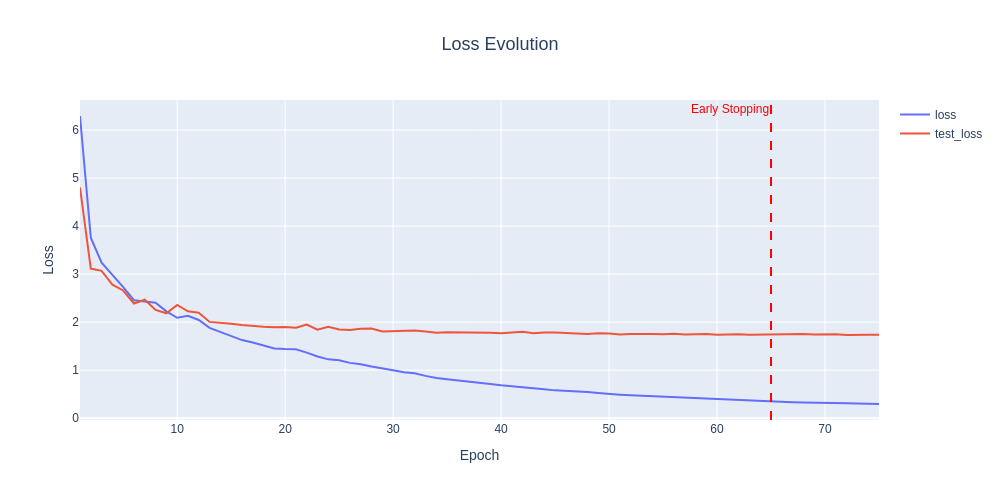

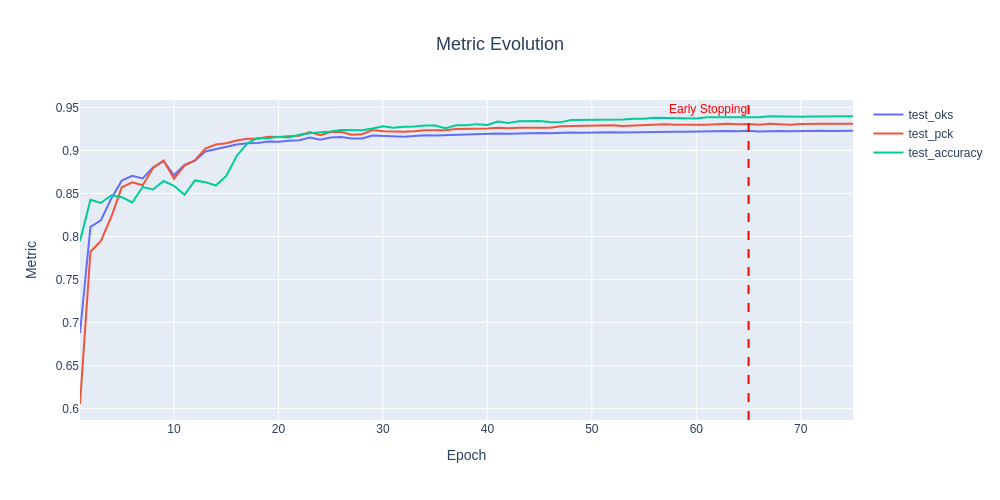

In [ ]:
# Static images for GitHub
plot_training_curves(history, history.columns[[0, 2]], idxmax, "png")
plot_training_curves(history, history.columns[3:], idxmax, "png")

### **Visualizing Pose Predictions**

In [ ]:
results = np.load(os.path.join(args.ckpt_dir, "inf_test_results_2d.npz"))

visualizer = PoseVisualizer(args.skeleton)
oks_metric = OKSMetric(args.oks_sigmas)
pck_metric = PCKMetric(args.alpha)

for k, v in results.items():
    print(k, v.shape)

images (5780, 256, 256, 3)
keypoints (5780, 15, 3)
bboxes (5780, 4)
keypoints_pred (5780, 15, 3)


In [ ]:
args.skeleton

{'back': [0, 9],
 'beak': [1, 1],
 'belly': [2, 3],
 'breast': [3, 14],
 'crown': [4, 5],
 'forehead': [5, 1],
 'left eye': [6, 5],
 'left leg': [7, 2],
 'left wing': [8, 0],
 'nape': [9, 4],
 'right eye': [10, 5],
 'right leg': [11, 2],
 'right wing': [12, 0],
 'tail': [13, 0],
 'throat': [14, 1]}

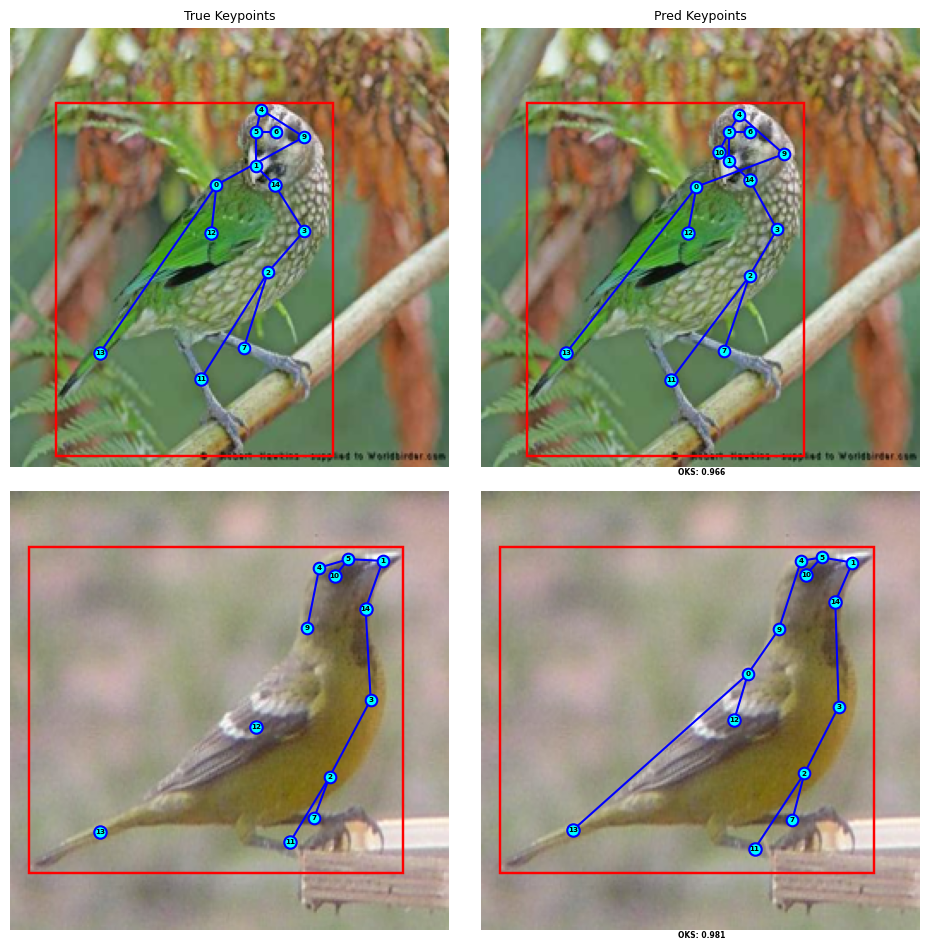

In [ ]:
visualizer.plot_keypoints(results, oks_metric)

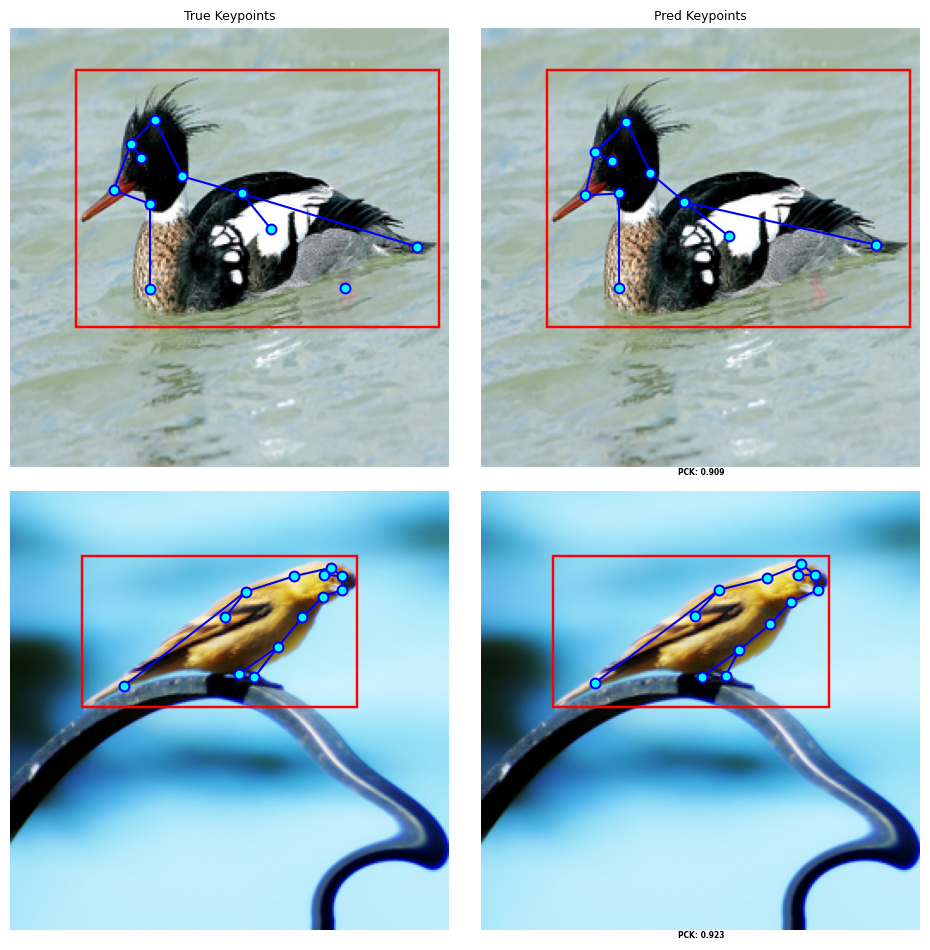

In [ ]:
visualizer.plot_keypoints(results, pck_metric, show_kpts_ids=False)

## **Final Model Evaluation (Single-Device)**

In distributed training using PyTorch's Distributed Data Parallel (DDP) strategy, when creating a `DistributedSampler` for a dataset whose size is not evenly divisible by the `world_size` (the number of processes, in this case GPUs), it is recommended to set `drop_last=True` to prevent duplicated samples during both training, evaluation and inference. Therefore, if the size of the validation or test dataset is not divisible by `world_size`, it is preferable to perform the evaluation on a single device after training to ensure 100% accuracy. In this case, the CUB-200-2011 dataset provides only a test split with 5,781 samples. Since two GPUs were used, only one sample was dropped, resulting in a negligible difference between distributed and single-device evaluation. 

For complete evaluation, the Kaggle single-GPU environment was used.

In [ ]:
!python train_ddp.py \
    --run_mode "evaluation" \
    --data_dir {data_dir} \
    --batch_size {batch_size} \
    --eval_set "test"

Devices available for evaluation:
 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)

Test dataset: size=5781, deleted_records=0

Total parameters of the trained model: 103,204,175

Test: 100%|██████████| 181/181 [01:20<00:00,  2.26it/s, test_loss=1.74, test_oks=0.923, test_pck=0.931, test_accuracy=0.938]


In [ ]:
# Load and compare multi-device vs single-device evaluation results
pd.DataFrame(
    [
        pd.read_csv(os.path.join(args.ckpt_dir, "test_results_2d.csv")).values.squeeze(),
        pd.read_csv(os.path.join(args.ckpt_dir, "test_results_1d.csv")).values.squeeze()
    ],
    columns=["Loss", "OKS", f"PCK@{args.alpha}", "Visibility Accuracy"],
    index=["multi-device evaluation", "complete evaluation"]
)

,Loss,OKS,PCK@0.05,Visibility Accuracy
multi-device evaluation,1.744363,0.922843,0.930526,0.938062
complete evaluation,1.744137,0.922844,0.930524,0.938061


## **Appendix: Single-Device Training (Google Colab)**

Additionally, the model will be trained for only 5 epochs on a Google Colab GPU, which is of the same type and has the same amount of VRAM as a single GPU in Kaggle's T4x2 environment. This allows measuring the training time difference between multi-GPU and single-device setups.

In [1]:
data_dir = "CUB-200-2011"
batch_size = 16

In [2]:
!python train_ddp.py \
    --data_dir {data_dir} \
    --epochs 5 \
    --batch_size {batch_size} \
    --lrf 7.5e-4 \
    --eval_set "test" \
    --monitor "test_oks"

Devices available for training:
 CUDA:0 (Tesla T4, 15095MiB)

model.safetensors: 100% 354M/354M [00:02<00:00, 133MB/s]
Train dataset: size=5990, deleted_records=0
 Test dataset: size=5781, deleted_records=0

Total model parameters: 103,204,175

Epoch 1/5
 Test: 100%|██████████| 362/362 [02:25<00:00,  2.48it/s, test_loss=4.22, test_oks=0.687, test_pck=0.62, test_accuracy=0.765]

Epoch 2/5
 Test: 100%|██████████| 362/362 [02:20<00:00,  2.57it/s, test_loss=3.65, test_oks=0.76, test_pck=0.708, test_accuracy=0.786]

Epoch 3/5
 Test: 100%|██████████| 362/362 [02:19<00:00,  2.60it/s, test_loss=3.24, test_oks=0.786, test_pck=0.752, test_accuracy=0.795]

Epoch 4/5
 Test: 100%|██████████| 362/362 [02:18<00:00,  2.60it/s, test_loss=3.26, test_oks=0.788, test_pck=0.756, test_accuracy=0.796]

Epoch 5/5
 Test: 100%|██████████| 362/362 [02:20<00:00,  2.57it/s, test_loss=2.84, test_oks=0.82, test_pck=0.798, test_accuracy=0.802]



In [ ]:
# Approximate speedup ratio: single-device epoch time / two-device epoch time
round((7*60 + 36 + 2*60 + 19) / (4*60 + 28 + 1*60 + 33), 2)

1.65

## **Conclusion**

Through distributed training with PyTorch using two GPUs, the **ConvNeXtBase U-Net** model, which comprises over 100M parameters, achieved an **OKS** of **0.923**, a **PCK@0.05** of **0.931**, and a **visibility accuracy** of **0.938** on the test set. This represented a speedup of approximately **1.65x** compared to single-GPU training. This pipeline can be generalized to accelerate the training, evaluation and inference phases for a wide range of computer vision or, more broadly, deep learning tasks using the **Distributed Data Parallel** strategy.

These metric results are nearly as high as those achieved with TensorFlow, despite the TensorFlow implementation using a larger input resolution (384x384) compared to this pipeline's (256x256) input. Furthermore, my [PoseEstimation_PyTorchXLA_TPU](https://github.com/JersonGB22/PoseEstimation-TensorFlow-PyTorch/tree/main/pytorch_xla_ddp/PoseEstimation_PyTorchXLA_TPU.ipynb) notebook implements a distributed training pipeline using **PyTorch/XLA**. That implementation demonstrates higher computational efficiency, outperforming both this **DDP** implementation and the distributed **TensorFlow** approach.